In [18]:
%autoreload 2

In [2]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
import sys, os, shutil
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from fish import Gafftopsail, Coelacanth
import behavior_finder as bhfd
import utils
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

pink = "#FB008C"
green = "#72D100"
cmap_conv = LinearSegmentedColormap.from_list("conv",[green, (1, 1, 1), pink])
cmap_conj = cm.get_cmap('coolwarm_r')

plt.rcParams.update({'font.size': 5})

C:\Users\Zichen\AppData\Local\Temp\ipykernel_32936\3014778103.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_conj = cm.get_cmap('coolwarm_r')


__BOUT FINDER__

In [3]:
path =r"C:\Data\Imaging//260425_overlap//All_behavior//"
all_df = []
all_saccade_df = []
fishlist = [
 r"C:\Data\Imaging\260415_overlap\fish3",r"C:\Data\Imaging\260415_overlap\fish3_2",
r"C:\Data\Imaging\260415_overlap\fish4", r"C:\Data\Imaging\260415_overlap\fish4_2",
     r"C:\Data\Imaging\260415_overlap\fish6", r"C:\Data\Imaging\260415_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish1", r"C:\Data\Imaging\260425_overlap\fish1_2",
r"C:\Data\Imaging\260425_overlap\fish2",r"C:\Data\Imaging\260425_overlap\fish2_2",
r"C:\Data\Imaging\260425_overlap\fish3",r"C:\Data\Imaging\260425_overlap\fish3_2",
r"C:\Data\Imaging\260425_overlap\fish5",r"C:\Data\Imaging\260425_overlap\fish5_2",
 r"C:\Data\Imaging\260425_overlap\fish6", r"C:\Data\Imaging\260425_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish7",r"C:\Data\Imaging\260425_overlap\fish7_2",
r"C:\Data\Imaging\260425_overlap\fish8",r"C:\Data\Imaging\260425_overlap\fish8_2",
r"C:\Data\Imaging\260425_overlap\fish9", r"C:\Data\Imaging\260425_overlap\fish9_2",
 r"C:\Data\Imaging\260425_overlap\fish10", r"C:\Data\Imaging\260425_overlap\fish10_2",
r"C:\Data\Imaging\260425_overlap\fish11", r"C:\Data\Imaging\260425_overlap\fish11_2",]
for f in fishlist:
    bout_df = pd.read_csv(f + '//Tail//tail_bout_df.csv', index_col=0, converters={
                "cont_tuples_tailindex": utils.parse_int_tuple,
                "cont_tuples_realtime_s":utils.parse_float_tuple,
                "tail_angle": float})
    bout_df.loc[:, 'tail_angle_norm'] = np.subtract(bout_df.tail_angle,bout_df[bout_df.tail_realstimuli == 'stationary'].tail_angle.mean())
    saccade_df = pd.read_csv(f + '//eye//proofread_eye_saccade_df.csv', index_col = 0,  converters={
                    "cont_tuples_eyeindex": lambda x: (int(x.split('(')[1].split(',')[0]),int(x.split(',')[1].split(')')[0])),
                    "cont_tuples_realtime_s": lambda x: (float(x.split('(')[1].split(',')[0]),float(x.split(',')[1].split(')')[0])),})

    bout_df.loc[:, "fish_id"] = f
    saccade_df.loc[:, 'fish_id'] = f
    all_df.append(bout_df)
    all_saccade_df.append(saccade_df)
    

all_df = pd.concat(all_df).reset_index(drop = True)
all_saccade_df = pd.concat(all_saccade_df).reset_index(drop = True)

stimulus_df = Gafftopsail(fishlist[0] + '//', filelist = ['stimulus']).stimulus_df
#stimulus_df =Coelacanth(f + '//', filelist = ['stimulus']).stimulus_df
stimulus_df.loc[:, "stim_name"] = [str(s) for s in stimulus_df.stim_name]

#for overlap fishes
omr_stim = [i for i in stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' not in i) and ('pause' not in i)]
dot_stim = [i for i in stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' in i) and ('pause' not in i)]
overlap_stim = [i for i in stimulus_df.stim_name.unique() if ('dot' in i) & ('[' in i)]
stimlists =[[str(['dot_l', 'forward']), str(['dot_l', 'left']), str(['dot_l', 'right']), str(['dot_l', 'backward']), str(['dot_r', 'forward']), str(['dot_r', 'left']), str(['dot_r', 'right']), str(['dot_r', 'backward'])], ['dot_l', 'dot_r']]
    #[['dot_l'], ['dot_r']]
    #[['forward'],[str(['dot_l', 'forward'])], [str(['dot_r', 'forward'])]]
#[['right'],[str(['dot_l', 'right'])], [str(['dot_r', 'right'])]]
    #[['left'],[str(['dot_l', 'left'])], [str(['dot_r', 'left'])]]
#[['backward'],[str(['dot_l', 'backward'])], [str(['dot_r', 'backward'])]]
#[['forward'],[str(['dot_l', 'forward'])], [str(['dot_r', 'forward'])]]


In [4]:
#for each bout, asslign the closest saccade and
max_diff_s = 1
all_diffs = []
all_convs = []
all_conjs = []
for fish in all_df.fish_id.unique():
    fish_bout_df = all_df[all_df.fish_id == fish]
    fish_saccade_df = all_saccade_df[all_saccade_df.fish_id == fish]
    bout_start_s = [float(i[0]) for i in fish_bout_df.cont_tuples_realtime_s]
    saccade_start_s = [float(i[0]) for i in fish_saccade_df.cont_tuples_realtime_s]
    diffs = [np.subtract(bs, saccade_start_s) for bs in bout_start_s]#positive: saccade -> bout, negative: bout-> saccade
    nearest_saccade_s = [diff[np.argmin(np.abs(diff))] for diff in diffs]
    nearest_saccade_s = [i if np.abs(i) <= max_diff_s else np.nan for i in nearest_saccade_s]
    nearest_saccade_conv = [fish_saccade_df['e_conv_change'].iloc[np.argmin(np.abs(diff))] for diff in diffs]
    nearest_saccade_conj = [fish_saccade_df['e_conj_change'].iloc[np.argmin(np.abs(diff))] for diff in diffs]
    all_diffs.extend(nearest_saccade_s)
    all_convs.extend(nearest_saccade_conv)
    all_conjs.extend(nearest_saccade_conj)
all_df.loc[:, 'nearest_saccade_s'] = all_diffs
all_df.loc[:, 'nearest_saccade_conv'] = all_convs
all_df.loc[:, 'nearest_saccade_conj'] = all_conjs

plotting 2p setup dot position
plotting 2p setup dot position


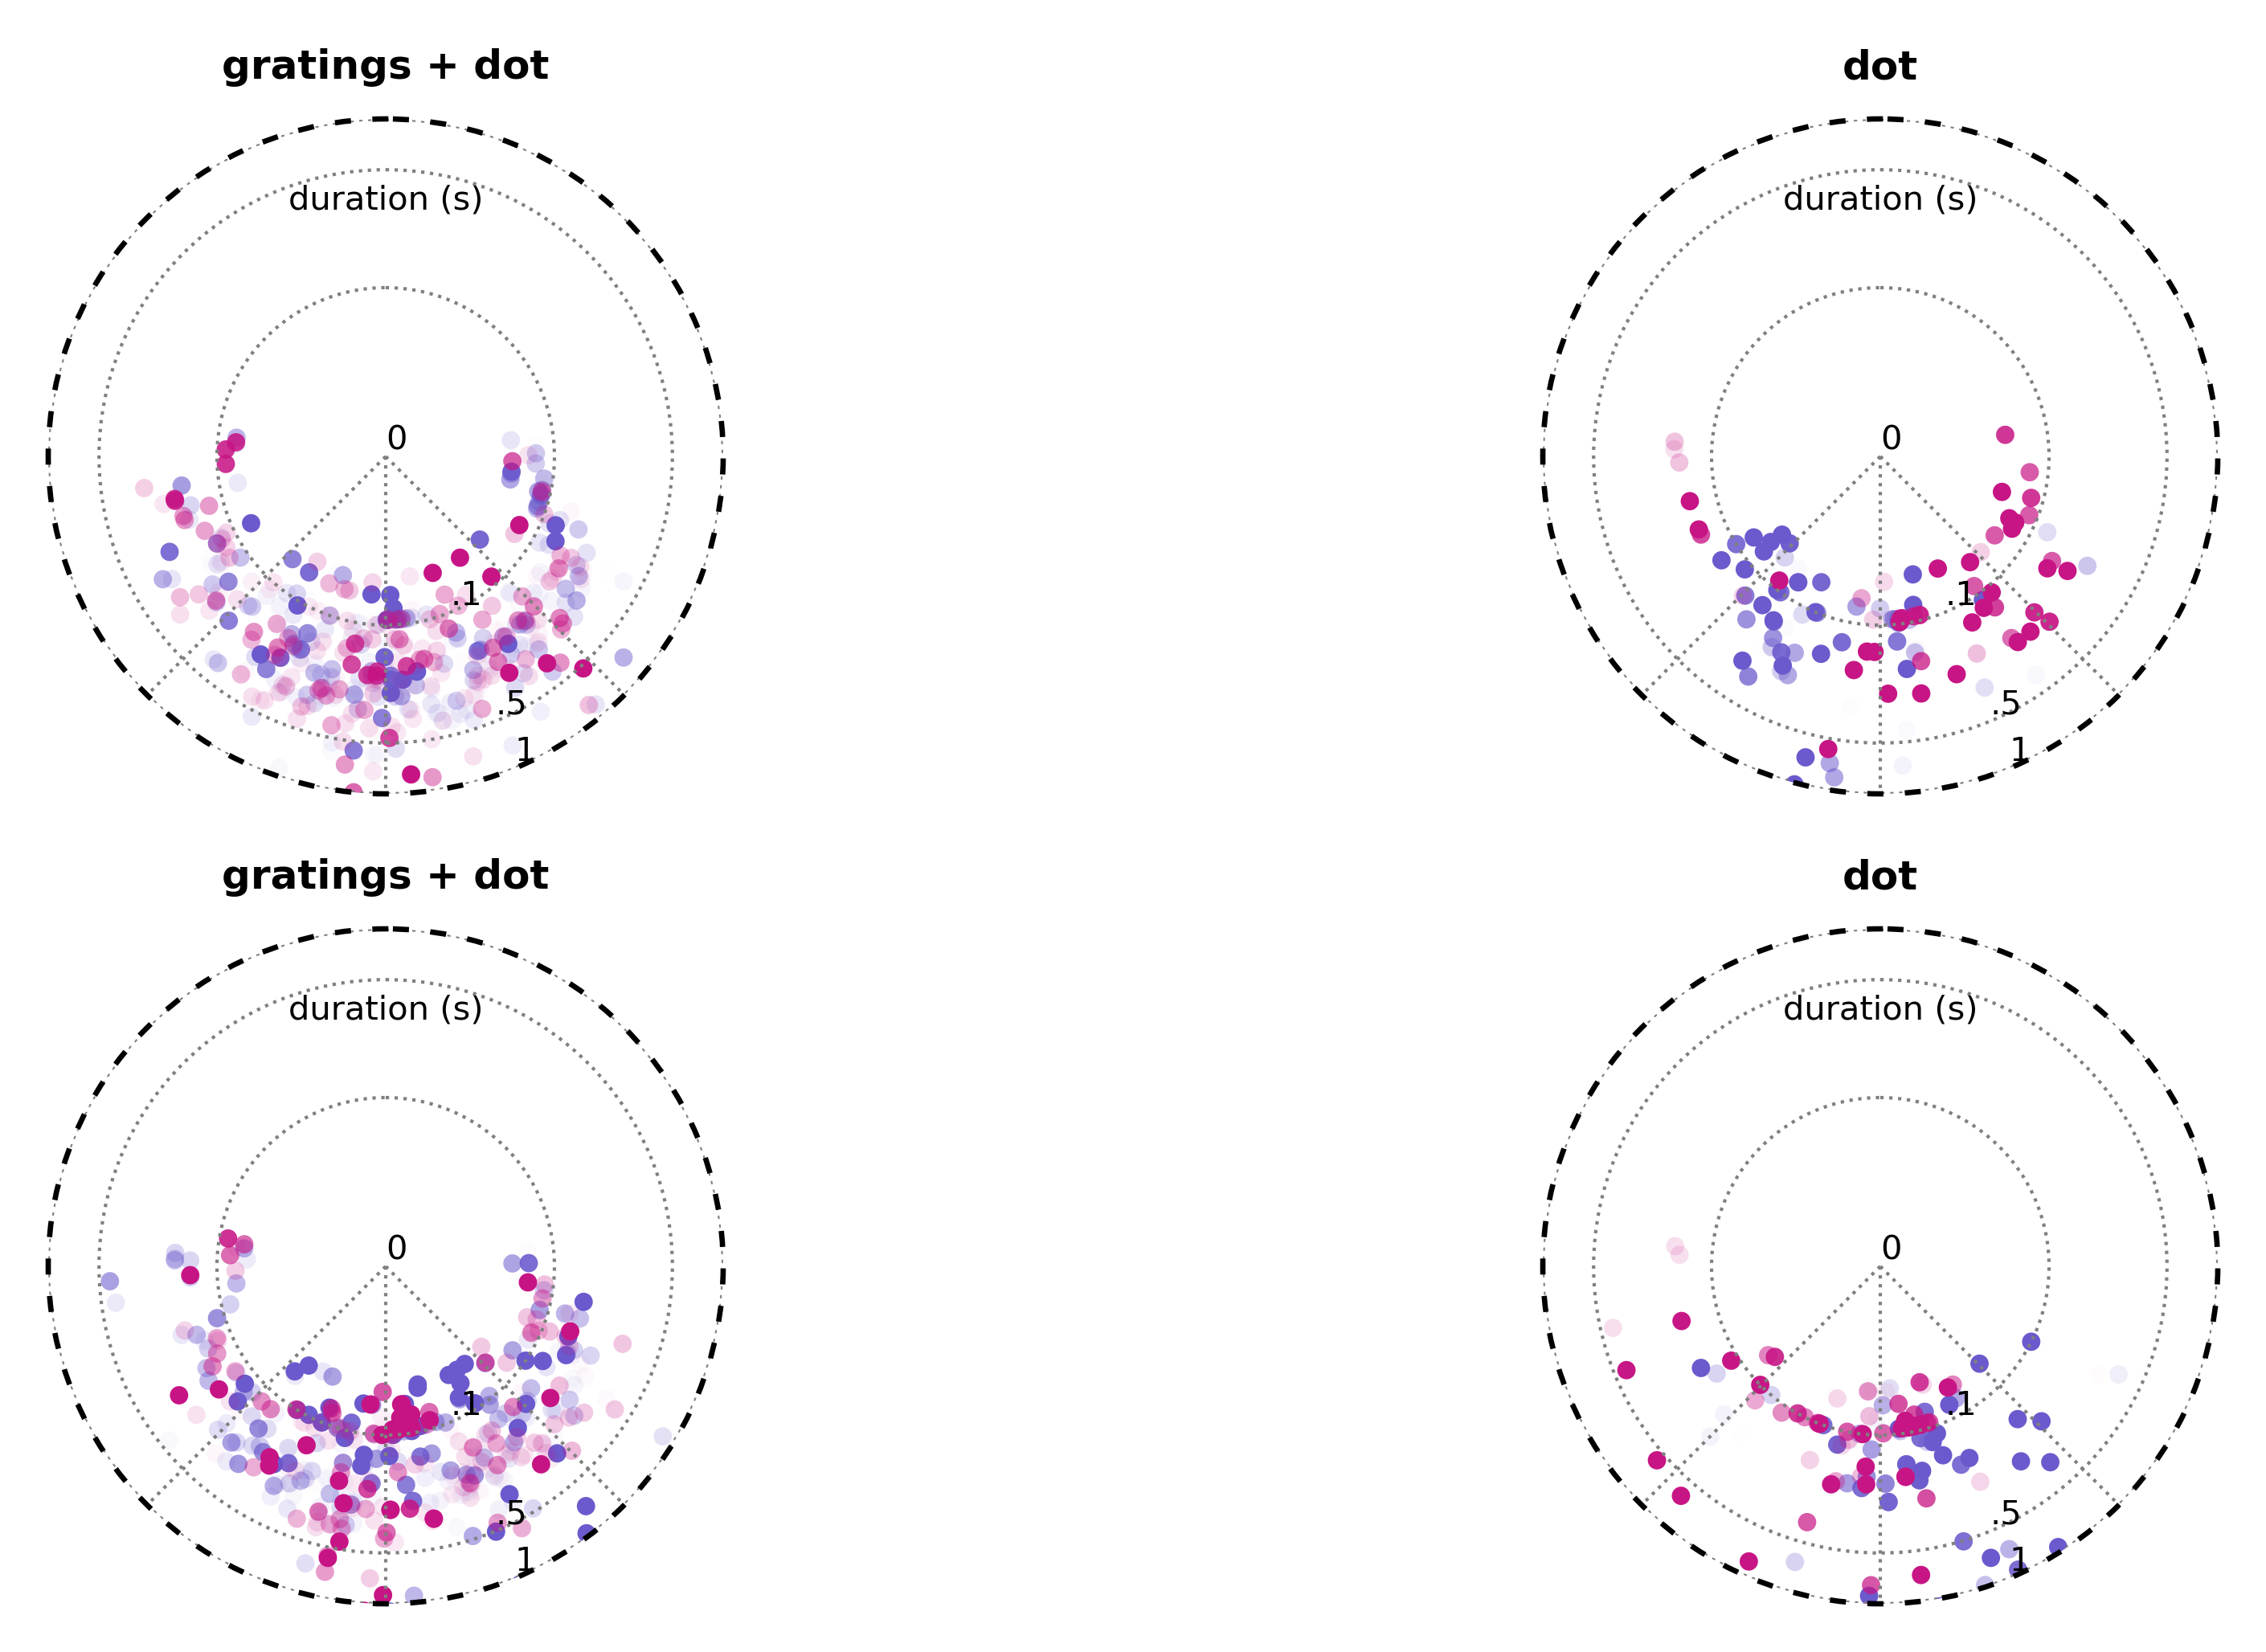

In [5]:
fig = bhfd.plot_boutangle_distribution(None, stimlists, s = 30, group = True, tail_bout_df = all_df, stimulus_df = stimulus_df)
fig.savefig(path+"//individual_bout_angle_overlaps.svg")
plt.show()
plt.close()

plotting 2p setup dot position
plotting 2p setup dot position


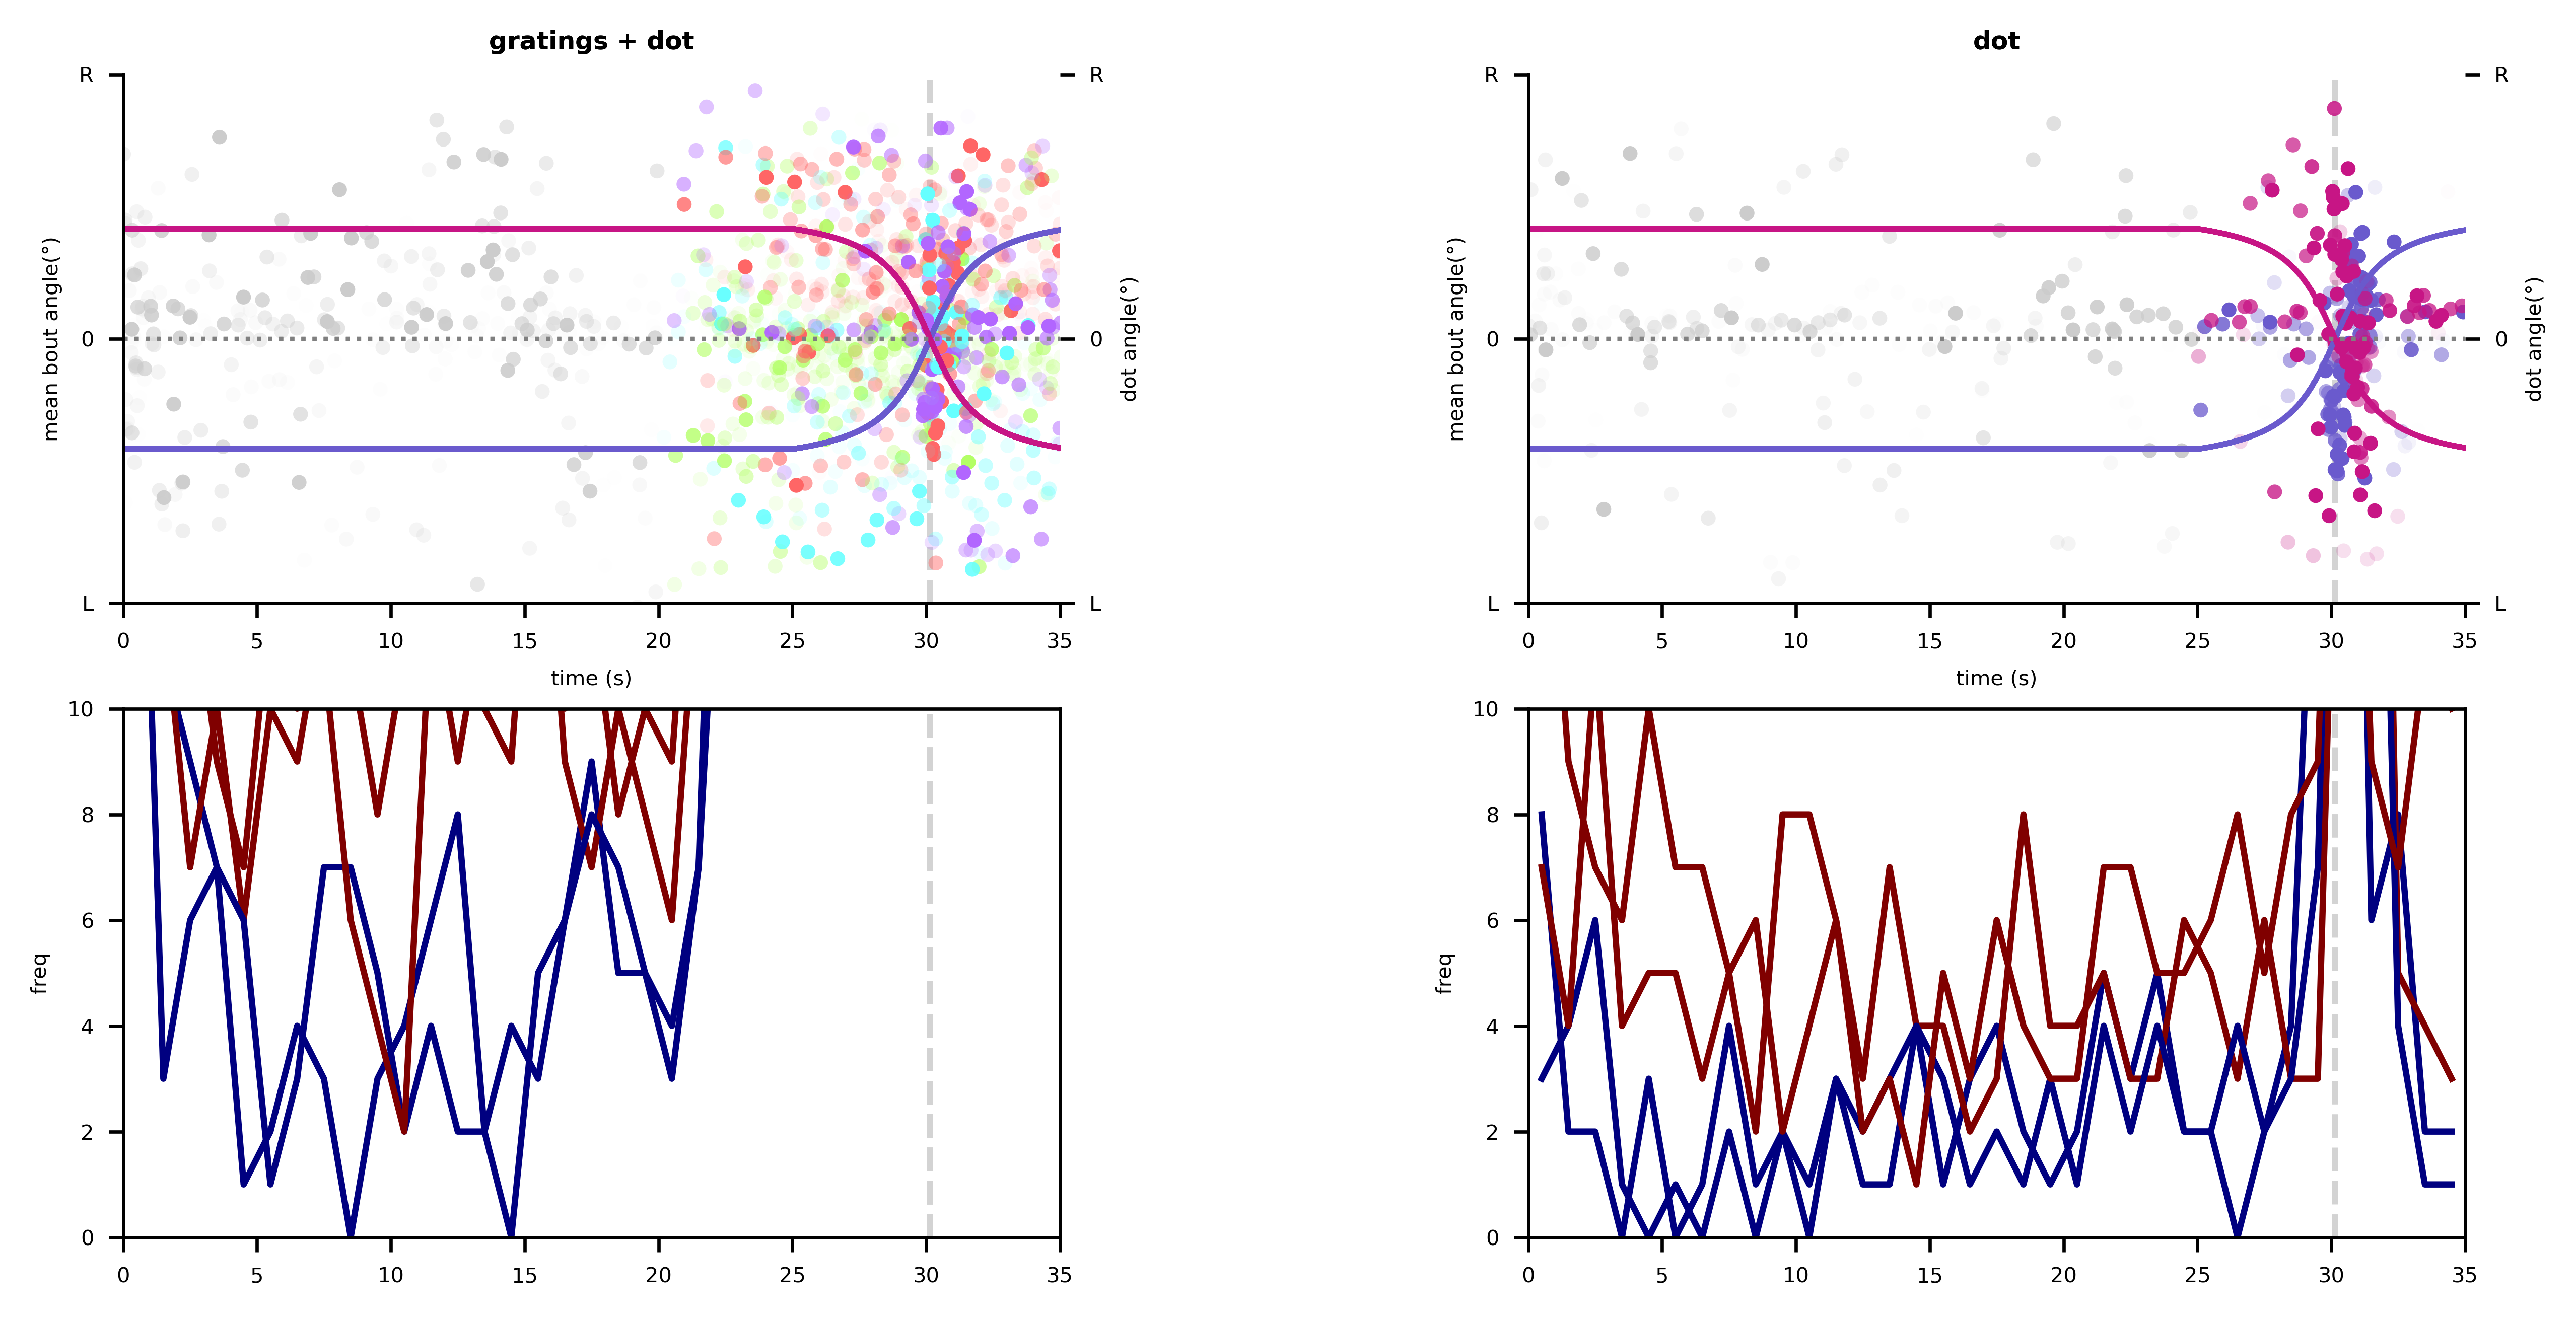

In [6]:
fig = bhfd.plot_bouttime_distribution(None, stimlists, s = 50, group = True, tail_bout_df = all_df, stimulus_df = stimulus_df)
fig.savefig(path+"//individual_bout_angle_acrosstime_overlaps.svg")
plt.show()
plt.close()



In [7]:
#look at it by fish
all_df.loc[:, 'fish_id_real'] = all_df['fish_id'].astype(str).str.replace(r'_\d+$', '', regex=True)
all_df_angle = all_df.drop(['cont_tuples_realtime_s', 'cont_tuples_tailindex', 'tail_stimuli', 'fish_id'], axis = 1).groupby(['tail_realstimuli', 'fish_id_real']).median().reset_index()
all_df_angle

,tail_realstimuli,fish_id_real,tail_strength,tail_angle,eye_vergence,tail_angle_pos,tail_angle_posmax,tail_angle_neg,tail_angle_negmin,tail_duration_s,tail_frequency_s,tail_fromstart_s,tail_angle_norm,nearest_saccade_s,nearest_saccade_conv,nearest_saccade_conj,eye_vergence_norm
0,"['dot_l', 'backward']",C:\Data\Imaging\260415_overlap\fish3,1.030578,-0.146870,-0.299544,0.822286,2.201623,-1.076004,-2.174497,0.336655,9.236871,26.445280,-0.132347,-0.650759,0.553152,-4.933933,0.073659
1,"['dot_l', 'backward']",C:\Data\Imaging\260415_overlap\fish6,0.200678,-0.118489,4.240736,0.132200,0.196842,-0.199723,-0.440094,0.133259,22.512632,31.215008,0.047004,-0.519609,21.644906,-13.327182,0.830244
2,"['dot_l', 'backward']",C:\Data\Imaging\260425_overlap\fish1,1.014305,0.085666,-3.859629,1.167940,3.039919,-1.230613,-2.312868,0.910672,5.490453,34.728054,-0.052459,NaN,8.730496,-17.581122,0.434106
3,"['dot_l', 'backward']",C:\Data\Imaging\260425_overlap\fish10,0.491879,1.085218,3.995464,1.085218,1.776208,NaN,NaN,0.172181,12.239789,31.199612,1.047914,-0.599896,3.510172,-3.490345,0.204001
4,"['dot_l', 'backward']",C:\Data\Imaging\260425_overlap\fish11,0.625472,-1.325018,12.671745,0.027100,0.037212,-1.325018,-2.065111,0.111048,12.863048,31.907720,-1.435003,-0.394945,12.329400,-23.035929,0.592741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,stationary,C:\Data\Imaging\260425_overlap\fish5,0.758738,-0.340370,-1.679785,1.058829,1.526368,-1.527421,-2.146993,0.084565,8.898236,11.706695,0.149034,-0.432842,-1.615987,-1.920328,0.000000
197,stationary,C:\Data\Imaging\260425_overlap\fish6,0.328383,0.116590,-0.015837,0.392867,0.883432,-0.102607,-0.157228,0.092988,13.461724,10.503928,0.018781,-0.450298,-3.813007,8.684960,0.000000
198,stationary,C:\Data\Imaging\260425_overlap\fish7,0.644645,-0.445736,1.833922,0.113205,0.173203,-0.575489,-0.809243,0.144374,13.853800,11.743582,-0.046343,-0.405416,0.469147,-0.848340,0.069956
199,stationary,C:\Data\Imaging\260425_overlap\fish8,0.390330,0.251100,0.147123,0.489600,0.832804,-0.146187,-0.176788,0.153567,11.477785,3.246319,0.036571,-0.504651,-2.447909,1.532345,0.000000


plotting 2p setup dot position
plotting 2p setup dot position


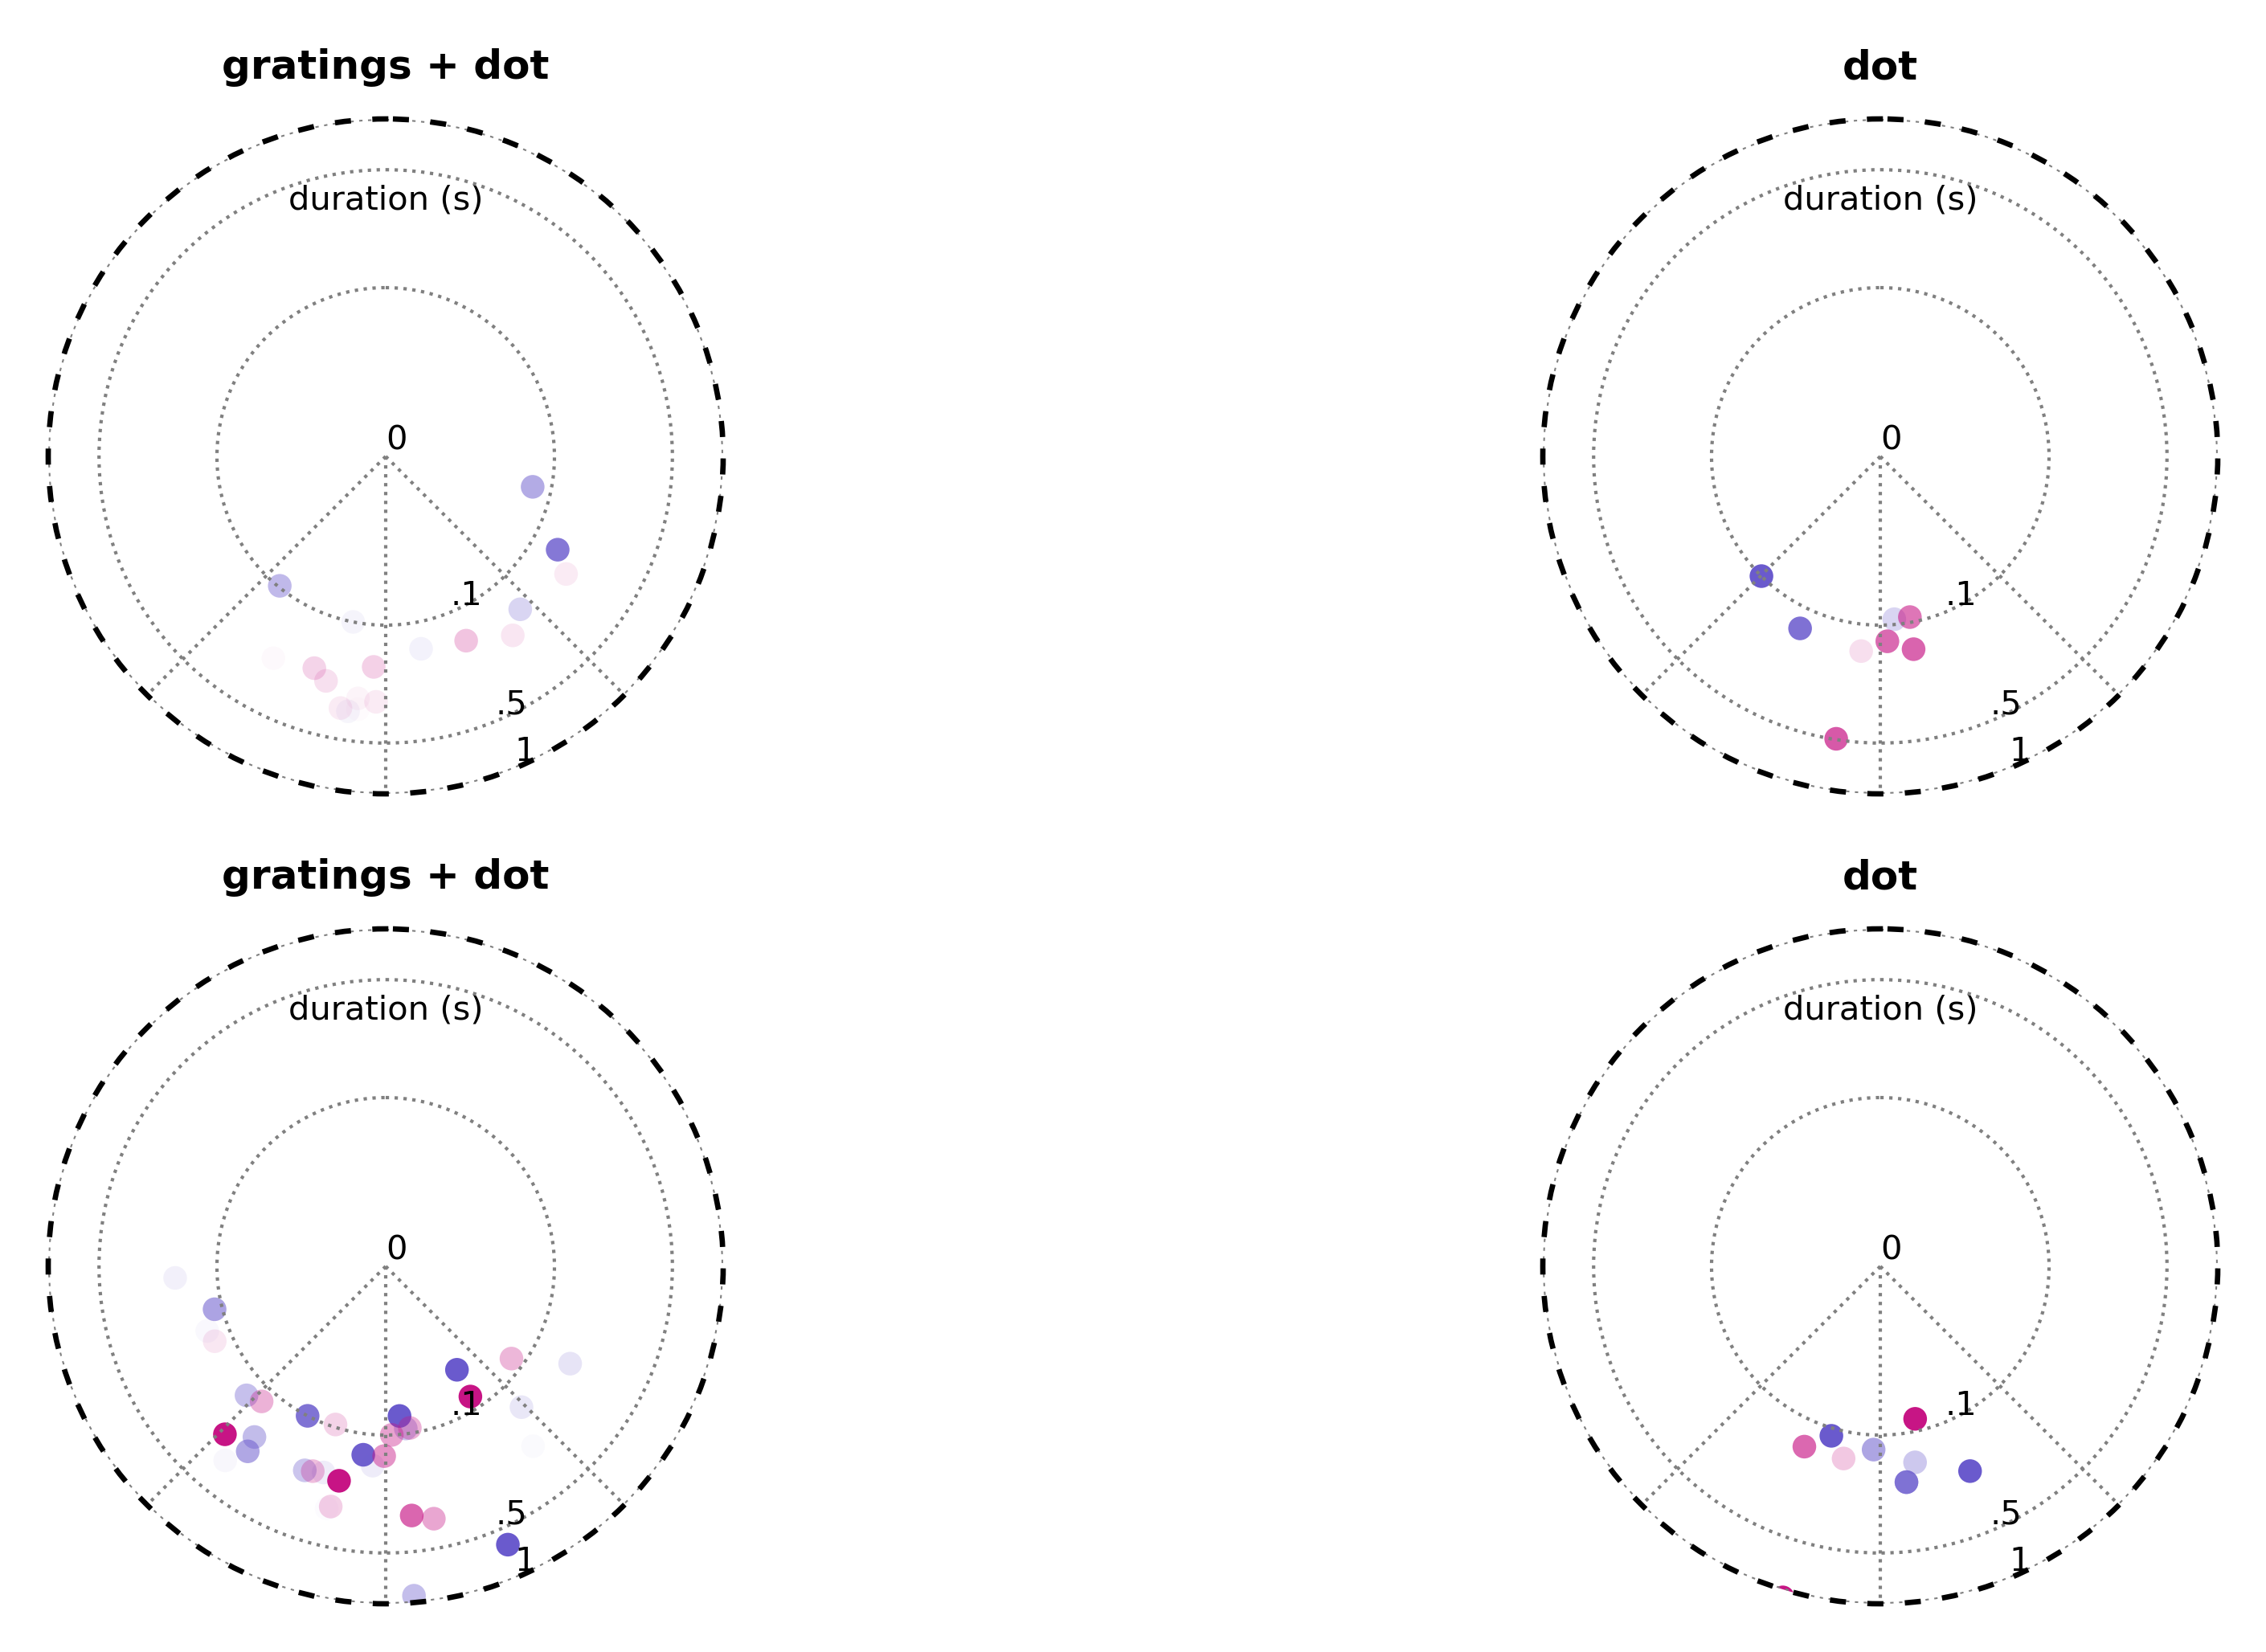

In [8]:
fig = bhfd.plot_boutangle_distribution(None, stimlists, s = 50, group = True, tail_bout_df = all_df_angle, stimulus_df = stimulus_df)
plt.show()
plt.close()
fig.savefig(path+"//individualfish_bout_angle_dot.svg")

plotting 2p setup dot position
plotting 2p setup dot position


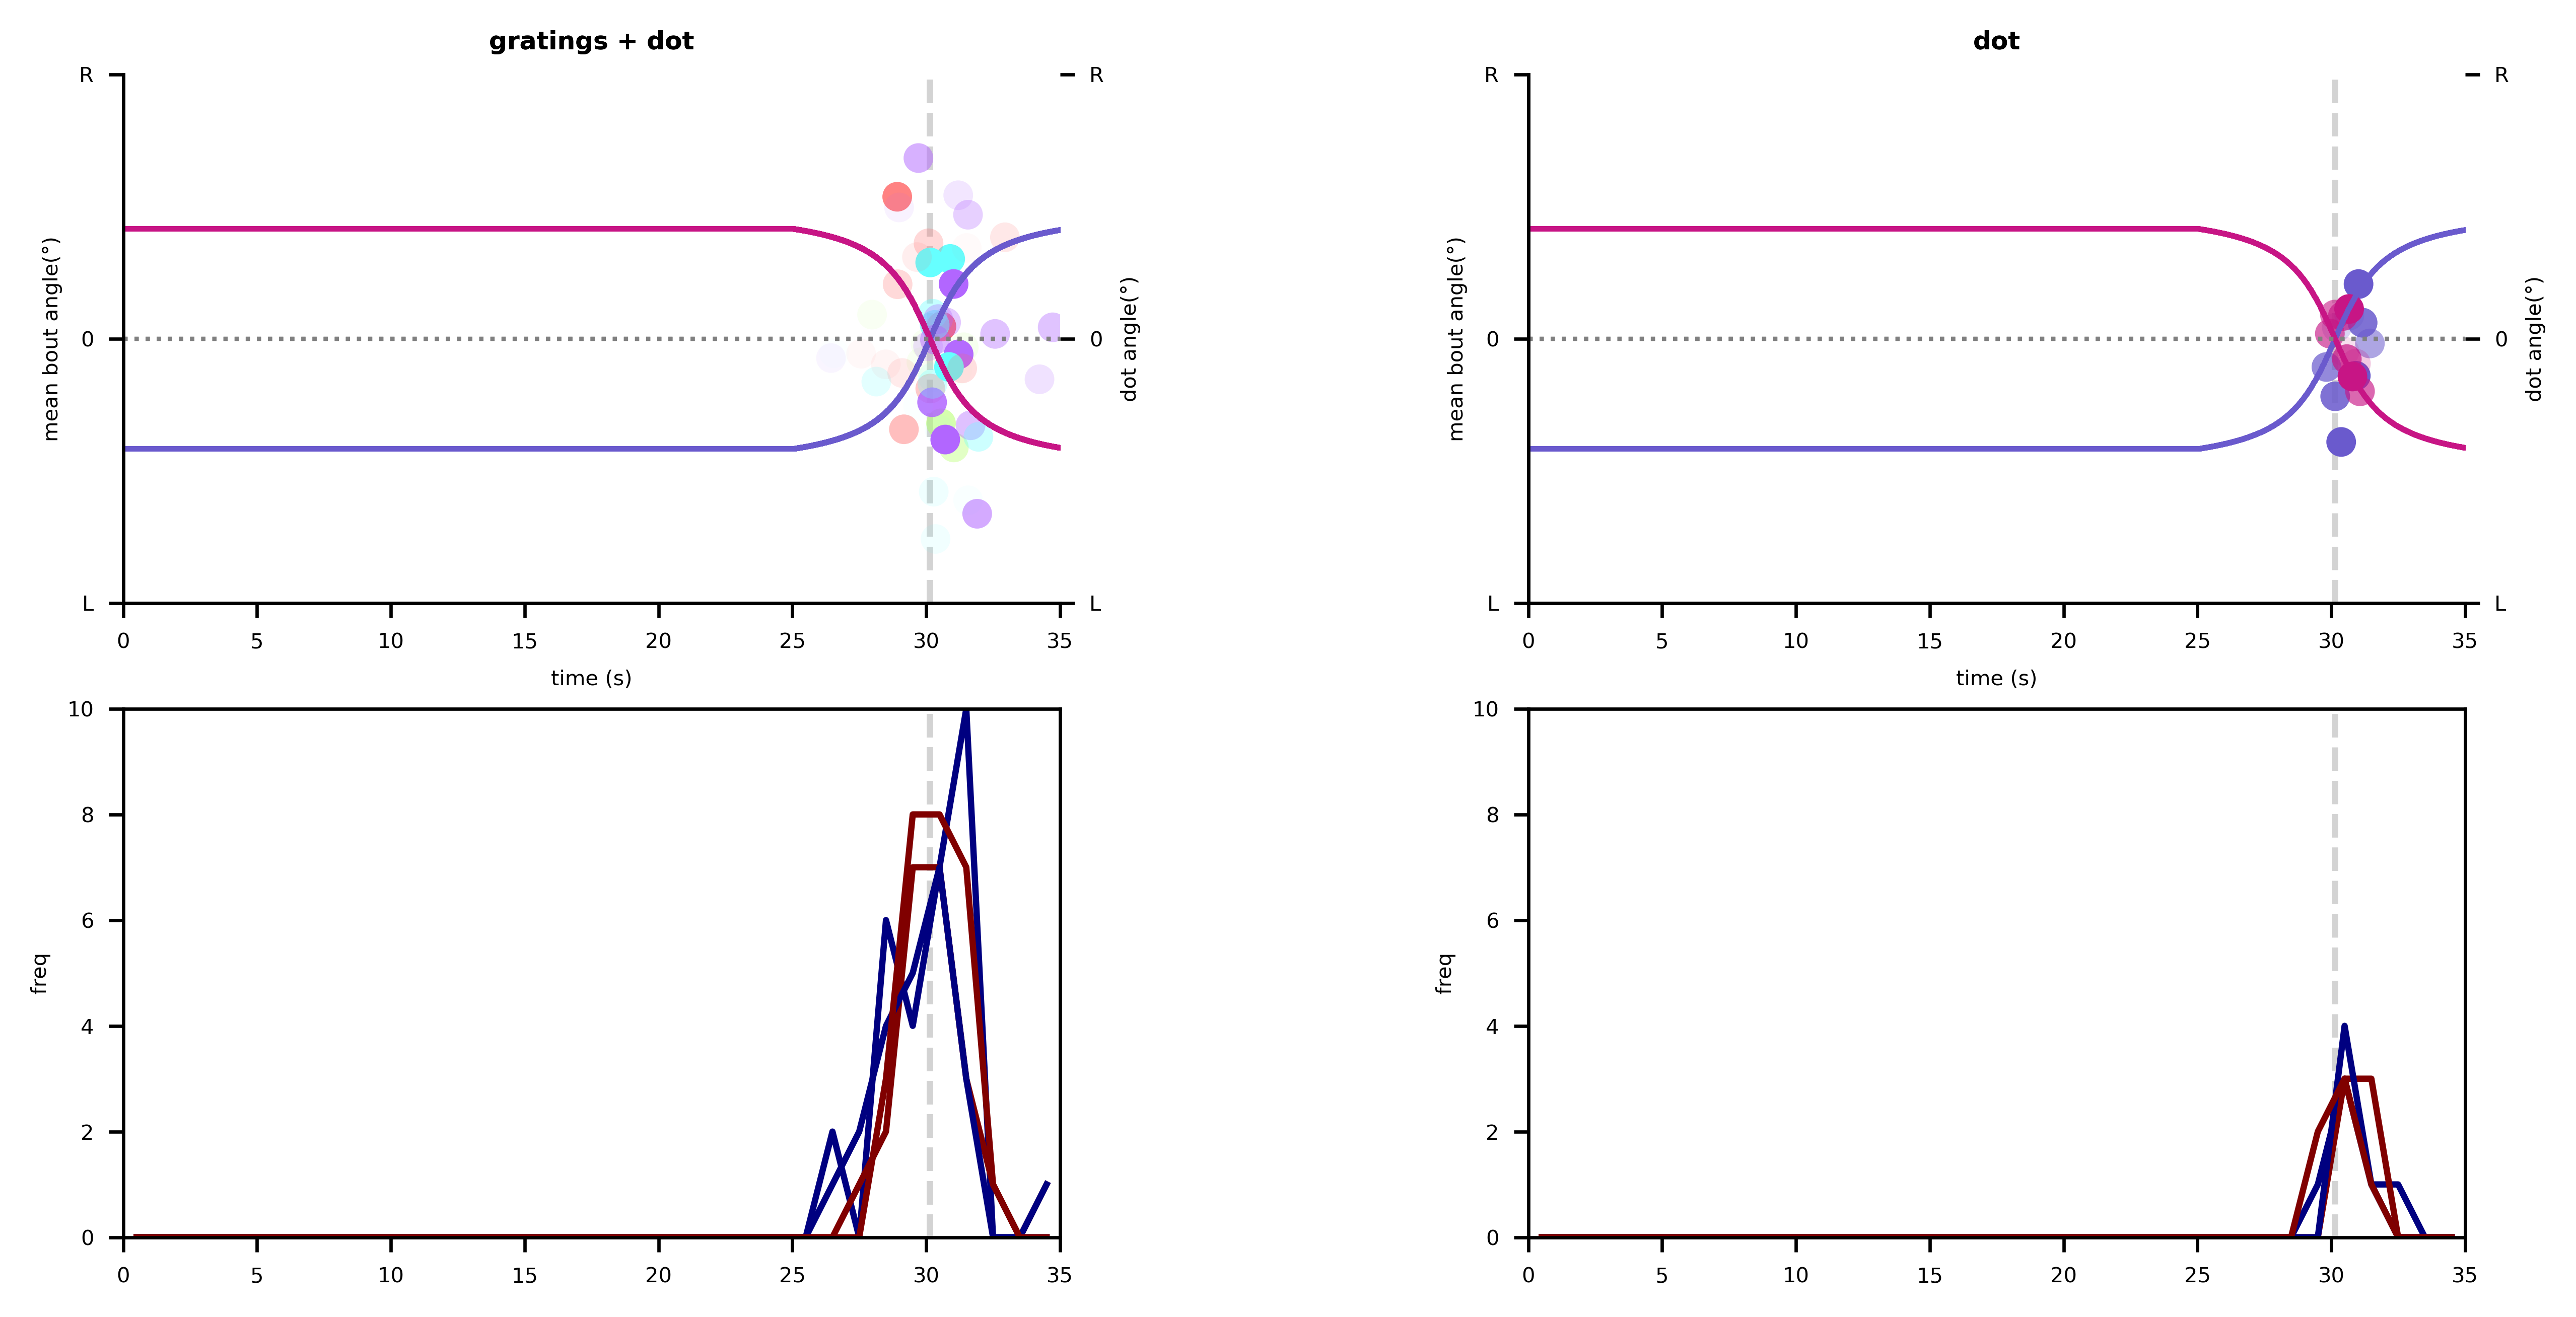

In [9]:
all_df_angle.loc[:, "tail_stimuli"] = all_df_angle.tail_realstimuli
fig = bhfd.plot_bouttime_distribution(None, stimlists, s = 200, group = True, tail_bout_df = all_df_angle, stimulus_df = stimulus_df)
plt.show()
plt.close()
fig.savefig(path+"//individualfish_bout_angle_acrosstime.svg")

plotting 2p setup dot position


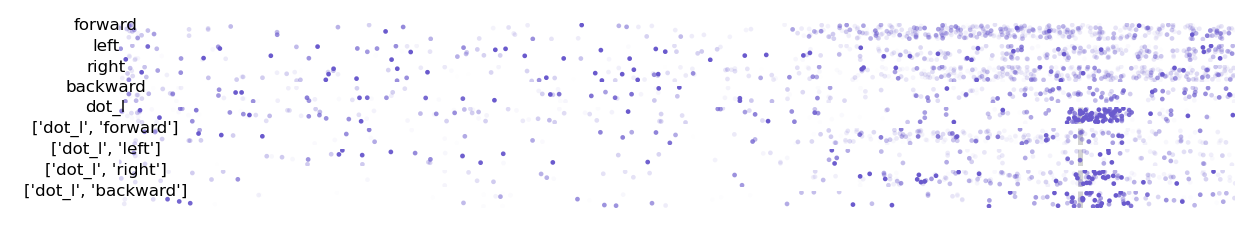

plotting 2p setup dot position


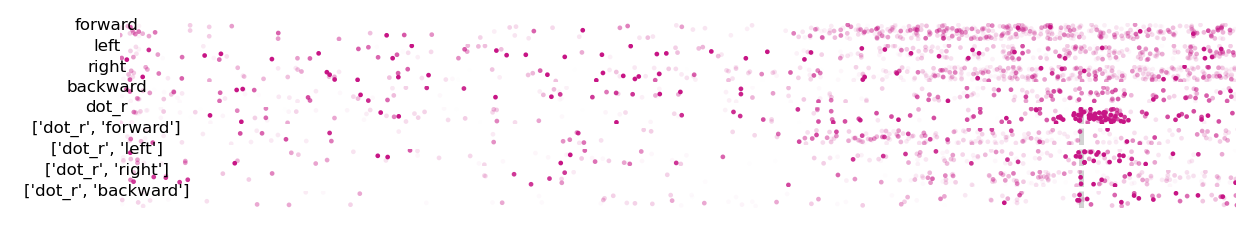

In [10]:
stim_list = ['forward', 'left', 'right', 'backward', 'dot_l', str(['dot_l', 'forward']), str(['dot_l', 'left']), str(['dot_l', 'right']), str(['dot_l', 'backward'])]
bhfd.plot_simple_nearestsaccade(all_df, stim_list, 'slateblue', stimulus_df)
plt.savefig(path + 'simple_bout_nearestsaccade_dotl.svg')
plt.show()
plt.close()

stim_list = ['forward', 'left', 'right', 'backward', 'dot_r',str(['dot_r', 'forward']), str(['dot_r', 'left']), str(['dot_r', 'right']),  str(['dot_r', 'backward'])]
bhfd.plot_simple_nearestsaccade(all_df, stim_list, 'mediumvioletred', stimulus_df)
plt.savefig(path + 'simple_bout_nearestsaccade_dotr.svg')
plt.show()
plt.close()


plotting 2p setup dot position


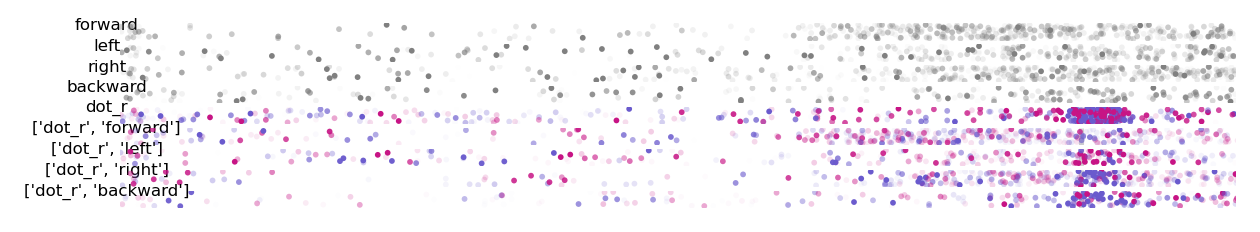

In [11]:
#new graph
stim_lists = [['forward'], ['left'], ['right'], ['backward'],
             ['dot_l', 'dot_r'],
             [str(['dot_l', 'forward']), str(['dot_r', 'forward'])],
              [str(['dot_l', 'left']), str(['dot_r', 'left'])],
              [str(['dot_l', 'right']), str(['dot_r', 'right'])],
              [str(['dot_l', 'backward']), str(['dot_r', 'backward'])]
    ]
bhfd.plot_simple_nearestsaccadecombine(all_df, stim_lists, stimulus_df)
plt.savefig(path + 'simple_bout_nearestsaccade_dots.svg')
plt.show()
plt.close()